# Church arithmetic inside an exact token machine

The [Boolean notebook](neural-boolean.ipynb) fixed the geometry-of-interaction
token machine for *linear* lambda terms and learned the gates as opaque boxes.
This notebook grows the machine to the **almost-linear fragment**: variables
may be copied, so `to_map` adds delta nodes of arbitrary arity and — new here —
an epsilon node for a variable that is never used, which makes Church zero and
predecessor expressible. The token now carries **two kinds of stack**: the
multiplicative stack of `λ`/`@` symbols, and one private **exponential stack of
copy indices per delta node**, recording which copy of a shared subterm the
token is in.

The machine stays a fixed, parameter-free function, exact by construction on
maps built from `λ`, `@`, `δ` and `ε` alone — verified below on Church
numerals, arithmetic, predecessor and subtraction, exponent towers and random
shared-variable polynomials. All the learning again concentrates in the
constants: `zero, one, two, three, plus, times, square` are opaque boxes
whose required behaviour, by GoI compositionality, is their reference term's
execution formula. Their innocent strategies collapse to **2–16 rules each**,
learnable by a two-layer MLP in seconds of JAX.

The scorecard, all exact: 91 training equations, 23 held-out compositions,
sums and products up to 32 with numerals **ten times larger than anything in
training** — the length generalization the [end-to-end
notebook](neural-lambda.ipynb) could not reach — and, pointing the decoder at
`λp.λq.plus(p)(q)`, the machine **reads the lambda term of addition itself
back out of the trained weights**, node by node.

In [1]:
import random
import time

import jax
import jax.numpy as jnp
import numpy as np

from discopy.closed import Abstraction, BohmTree, Unitype, Variable

o = Unitype()
tree = BohmTree.from_term


def church(n):
    def body(f):
        def inner(x):
            result = x
            for _ in range(n):
                result = f(result)
            return result
        return o(inner)
    return o(body)


add = o(lambda m: o(lambda n: o(lambda f: o(lambda x: m(f)(n(f)(x))))))
mult = o(lambda m: o(lambda n: o(lambda f: m(n(f)))))
exponent = o(lambda m: o(lambda n: n(m)))

for a in range(4):
    for b in range(4):
        assert tree(add(church(a))(church(b))) == tree(church(a + b))
        assert tree(mult(church(a))(church(b))) == tree(church(a * b))
assert tree(exponent(church(2))(church(3))) == tree(church(8))
print("the reference constants compute: OK")

the reference constants compute: OK


## Almost-linear terms are combinatorial maps

`to_map` extends Zeilberger's bijection: abstraction and application are
trivalent gamma nodes, a variable used `n` times goes through one **delta**
node with `n` ports, a variable never used plugs its abstraction into a
univalent **epsilon** node, and a constant is a univalent box. Church two has
one delta — its `f` is used twice — and Church zero has one epsilon.

church(2): ['@', '@', 'δ', 'λ', 'λ']
church(0): ['ε', 'λ', 'λ']


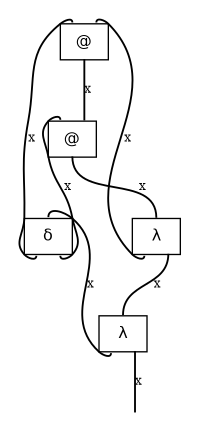

In [2]:
two_map, zero_map = church(2).to_map(), church(0).to_map()
print("church(2):", sorted(box.name for box in two_map.boxes))
print("church(0):", sorted(box.name for box in zero_map.boxes))
two_map.draw()

## The exact token machine, now with two kinds of stack

One token, one multiplicative stack, and one private exponential stack per
delta. The gamma rules are those of the Boolean notebook: auxiliary entry
pushes the one-hot of its port, principal entry pops and routes. The delta
rules are their exponential shadow:

* entering a delta through **occurrence port** `i` pushes `i` onto *that
  delta's own stack* and exits toward the shared subterm;
* entering through the **principal** pops the index and returns to that
  occurrence.

A pop always finds the index the matching push left, because the visits of a
single legal path to one delta's copies are well-bracketed — this is the
naive pairing of sharing graphs, one private stack per fan. An opaque box
namespaces its reference map's deltas under its own prefix, so boxes nest
without collisions and a box's pending copy indices travel *inside the
token* between visits.

In [3]:
ROLES = {"@": (0, (2, 1)), "λ": (1, (0, 2))}
L0, L1, A0, A1 = ("λ", 0), ("λ", 1), ("@", 0), ("@", 1)
TABLES = {}


def logical_ports(cmap, index):
    ports = cmap._box_port_indices[index]
    arity = len(cmap.boxes[index].dom)
    return ports[:arity] + tuple(reversed(ports[arity:]))


def port_table(cmap):
    if id(cmap) not in TABLES:
        table = {}
        for index, box in enumerate(cmap.boxes):
            for wire, port in enumerate(logical_ports(cmap, index)):
                table[port] = (index, box.name, wire)
        TABLES[id(cmap)] = (cmap, table)
    return TABLES[id(cmap)][1]


def run(cmap, mult_, exp=None, prefix=(), max_steps=1_000_000, boxes=None):
    """Run the token from the root; return the exit stacks or ``None``s."""
    root, table = cmap.n_ports - 1, port_table(cmap)
    port, mult_, exp = cmap.edges[root], tuple(mult_), dict(exp or {})
    for _ in range(max_steps):
        if port == root:
            return mult_, {key: stack for key, stack in exp.items() if stack}
        if port not in table:
            return None, None
        index, name, wire = table[port]
        if name in ROLES:
            principal, auxes = ROLES[name]
            if wire == principal:
                if not mult_:
                    return None, None
                (_, j), mult_ = mult_[0], mult_[1:]
                out_wire = auxes[j]
            else:
                mult_ = ((name, auxes.index(wire)), ) + mult_
                out_wire = principal
        elif name == "δ":
            key, stack = prefix + (index, ), exp.get(prefix + (index, ), ())
            if wire == 0:
                if not stack:
                    return None, None
                j, exp[key] = stack[0], stack[1:]
                out_wire = 1 + j
            else:
                exp[key] = (wire - 1, ) + stack
                out_wire = 0
        elif name == "ε":
            return None, None
        else:
            state = boxes[name](mult_, exp, prefix + (index, ))
            if state is None:
                return None, None
            mult_, exp = state[0], dict(state[1])
            out_wire = wire
        port = cmap.edges[logical_ports(cmap, index)[out_wire]]
    return None, None

## Böhm-tree readback through the deltas

The probe protocol of the Boolean notebook survives with one addition. There,
a probe was a multiplicative path; the machine now also needs to know which
copy each delta on the way down should route to. But the parent's own probe
already answered that: its **exit exponential state records the copy indices
of its head path**, in exactly the order the child's descent pops them. So
the extractor threads each response's exponential state into the probes of
its children, and readback stays deterministic and exact.

In [4]:
def strip_run(seq, symbol):
    count = 0
    while count < len(seq) and seq[count] == symbol:
        count += 1
    return count, seq[count:]


def parse_own(rest, pad):
    local, rest = strip_run(rest, L0)
    if not rest or rest[0] != L1:
        return None
    arity, rest = strip_run(rest[1:], A0)
    tail, rest = strip_run(rest, L0)
    return None if rest else (local, arity, pad - tail)


def extract(cmap, pad=16, max_nodes=200, max_steps=1_000_000, boxes=None):
    """Exact Böhm-tree readback: {address: (binders, head, arity)}."""
    nodes, entry_paths, head_paths, entry_exps = {}, {}, {}, {}
    scopes, level_of, mu_of = {}, {}, {}

    def climb(node):
        if node == ():
            return ()
        parent = node[:-1]
        hops = (A1, ) + (A0, ) * node[-1] + (L1, )
        local = level_of[parent] - scopes[mu_of[parent][:-1]]\
            if mu_of[parent] else level_of[parent]
        return hops + (L0, ) * local + climb(mu_of[parent])

    todo = [((), (), {})]
    while todo and len(nodes) < max_nodes:
        address, entry, entry_exp = todo.pop(0)
        response, response_exp = run(
            cmap, entry + (L0, ) * pad, entry_exp,
            max_steps=max_steps, boxes=boxes)
        parsed = None
        if response is not None:
            candidates = sorted(
                [address[:d] for d in range(len(address), -1, -1)],
                key=lambda mu: -len(climb(mu)))
            for mu in candidates:
                junk = tuple(reversed(climb(mu)))
                own = parse_own(response[len(junk):], pad)\
                    if response[:len(junk)] == junk else None
                if own is not None:
                    parsed = (mu, ) + own
                    break
        if parsed is None:
            nodes[address] = None
            continue
        mu, local, arity, n_binders = parsed
        scopes[address] = (scopes[address[:-1]] if address else 0) + n_binders
        level = (scopes[mu[:-1]] if mu else 0) + local
        nodes[address] = (n_binders, level, arity)
        level_of[address], mu_of[address] = level, mu
        entry_paths[address] = entry
        head_paths[address] = entry_paths[mu] + (L0, ) * local + (L1, )
        entry_exps[address] = response_exp
        for j in range(arity):
            todo.append((address + (j, ),
                         head_paths[address] + (A0, ) * j + (A1, ),
                         entry_exps[address]))
    return nodes


def tree_nodes(term):
    result = {}

    def walk(t, address):
        result[address] = (len(t.variables), t.head, len(t.args))
        for j, arg in enumerate(t.args):
            walk(arg, address + (j, ))
    walk(tree(term), ())
    return result


def exact(term, truth=None):
    got = extract(term.to_map(), pad=24, max_nodes=400)
    return got == tree_nodes(term if truth is None else truth)

In [5]:
start = time.time()
assert all(exact(church(n)) for n in range(6))

square = o(lambda n: mult(n)(n))
assert exact(add(church(2))(church(3)), church(5))
assert exact(mult(church(3))(add(church(2))(church(2))), church(12))
assert exact(square(church(4)), church(16))
assert exact(o(lambda n: mult(n)(mult(n)(n)))(church(2)), church(8))
assert exact(exponent(church(2))(church(3)), church(8))
assert exact(exponent(exponent(church(2))(church(2)))(church(2)), church(16))
print("numerals, arithmetic, shared squares and cubes, exponent towers: OK")

pred = o(lambda n: o(lambda f: o(lambda x:
    n(o(lambda g: o(lambda h: h(g(f)))))(o(lambda u: x))(o(lambda u: u)))))
sub = o(lambda m: o(lambda n: n(pred)(m)))
assert all(exact(pred(church(k)), church(max(0, k - 1))) for k in range(5))
assert all(exact(sub(church(m))(church(n)), church(max(0, m - n)))
           for m, n in [(3, 1), (4, 2), (2, 2), (1, 3)])
print("pred and sub, through the epsilon nodes: OK")

numerals, arithmetic, shared squares and cubes, exponent towers: OK


pred and sub, through the epsilon nodes: OK


The machine is exact on random polynomials with shared variables — any
mix of literals, `add`, `mult` and `exponent` over copied inputs, checked
against syntactic beta reduction.

In [6]:
def random_poly(rng, depth, n_vars):
    if depth == 0 or rng.random() < 0.3:
        if n_vars and rng.random() < 0.5:
            return ("var", rng.randrange(n_vars))
        return ("lit", rng.randrange(4))
    op = rng.choice(["add", "mult", "exp"])
    return (op, random_poly(rng, depth - 1, n_vars),
            random_poly(rng, depth - 1, n_vars))


def to_int(expr, env):
    if expr[0] == "var":
        return env[expr[1]]
    if expr[0] == "lit":
        return expr[1]
    a, b = to_int(expr[1], env), to_int(expr[2], env)
    return {"add": a + b, "mult": a * b, "exp": a ** b}[expr[0]]


def uses(expr, index):
    if expr[0] == "var":
        return int(expr[1] == index)
    return sum(uses(s, index) for s in expr[1:]) if len(expr) > 2 else 0


def self_applies(expr):
    if len(expr) < 3:
        return False
    if expr[0] == "exp" and any(
            uses(expr[1], i) and uses(expr[2], i) for i in range(3)):
        return True
    return any(self_applies(s) for s in expr[1:])


def to_term(expr, xs):
    if expr[0] == "var":
        return xs[expr[1]]
    if expr[0] == "lit":
        return church(expr[1])
    op = {"add": add, "mult": mult, "exp": exponent}[expr[0]]
    return op(to_term(expr[1], xs))(to_term(expr[2], xs))


rng, n_checked = random.Random(7), 0
for trial in range(100):
    n_vars = rng.randrange(3)
    expr = random_poly(rng, rng.randrange(1, 4), n_vars)
    values = [rng.randrange(4) for _ in range(n_vars)]
    if to_int(expr, values) > 40 or self_applies(expr):
        continue
    xs = [Variable(f"x{i}", o) for i in range(n_vars)]
    term = to_term(expr, xs)
    for x in reversed(xs):
        term = Abstraction(x, term)
    for v in values:
        term = term(church(v))
    assert exact(term), (trial, expr, values)
    n_checked += 1
print(f"{n_checked} random shared-variable polynomials: OK "
      f"({time.time() - start:.1f}s for the whole battery)")

89 random shared-variable polynomials: OK (5.9s for the whole battery)


## The frontier: self-application of a shared variable

One family is excluded above, and honestly so: a variable shared across the
two sides of an exponentiation, `x^x = x(x)` with `x` bound. There the two
copies of the shared numeral interact *with each other*, the visits to the
delta stop being well-bracketed, and the naive pairing breaks — this is
exactly where Lévy-optimal sharing graphs need Lamping's bracket oracle.
Everything up to it — shared numerals in sums, products and towers of
literals — the private stacks handle exactly.

In [7]:
x_to_the_x = o(lambda x: exponent(x)(x))(church(2))
assert tree(x_to_the_x) == tree(church(4))  # beta reduction says 2^2 = 4
assert extract(x_to_the_x.to_map(), pad=24)[()] is None  # the machine loops
print("x^x is where the naive pairing stops: the probe finds no answer")

x^x is where the naive pairing stops: the probe finds no answer


## GoI compositionality: oracles and the two-stack watermark

A constant is a univalent box; by compositionality of the execution formula
its required behaviour is its reference map's own, run inside the host's
token. Every oracle call is a labelled visit
``(mult_in, own_in) -> (mult_out, own_out)``, where ``own`` is the box's
private exponential state — pending copy indices that persist between visits
*inside the token*. The watermark of the Boolean notebook now tracks the
minimum depth of **each** stack: below it, both tails provably ride through,
so a visit reduces to the rule ``read prefixes -> rewritten heads``. A box
inside a reference (as `times` is inside `square`) reports its own read
depths upward, so the watermark stays exact through nesting.

In [8]:
def run_watermarked(cmap, mult_, exp, prefix, boxes,
                    max_steps=1_000_000):
    """Like ``run``, also returning the minimum depth of each stack."""
    root, table = cmap.n_ports - 1, port_table(cmap)
    port, mult_, exp = cmap.edges[root], tuple(mult_), dict(exp or {})
    low = {"mult": len(mult_)}
    for _ in range(max_steps):
        low["mult"] = min(low["mult"], len(mult_))
        for key, stack in exp.items():
            low[key] = min(low.get(key, len(stack)), len(stack))
        if port == root:
            return mult_, {k: v for k, v in exp.items() if v}, low
        if port not in table:
            return None, None, low
        index, name, wire = table[port]
        if name in ROLES:
            principal, auxes = ROLES[name]
            if wire == principal:
                if not mult_:
                    return None, None, low
                (_, j), mult_ = mult_[0], mult_[1:]
                out_wire = auxes[j]
            else:
                mult_ = ((name, auxes.index(wire)), ) + mult_
                out_wire = principal
        elif name == "δ":
            key, stack = prefix + (index, ), exp.get(prefix + (index, ), ())
            low[key] = min(low.get(key, len(stack)), len(stack))
            if wire == 0:
                if not stack:
                    return None, None, low
                j, exp[key] = stack[0], stack[1:]
                out_wire = 1 + j
            else:
                exp[key] = (wire - 1, ) + stack
                out_wire = 0
        elif name == "ε":
            return None, None, low
        else:
            state = boxes[name](mult_, exp, prefix + (index, ))
            if state is None:
                return None, None, low
            box_read, box_exp_reads = state[2]
            low["mult"] = min(low["mult"], len(mult_) - box_read)
            for key, box_read_k in box_exp_reads.items():
                depth = len(exp.get(key, ())) - box_read_k
                low[key] = min(low.get(key, depth), depth)
            mult_, exp = state[0], dict(state[1])
            out_wire = wire
        port = cmap.edges[logical_ports(cmap, index)[out_wire]]
    return None, None, low


class RecordingOracle:
    """An oracle box that logs every visit as a watermarked rule."""

    def __init__(self, name, ref_cmap, boxes=None):
        self.name, self.ref_cmap = name, ref_cmap
        self.boxes, self.visits = boxes or {}, []

    def __call__(self, mult_in, exp, me):
        own_in = {key[len(me):]: stack for key, stack in exp.items()
                  if key[:len(me)] == me}
        mult_out, exp_out, low = run_watermarked(
            self.ref_cmap, mult_in, exp, me, self.boxes)
        if mult_out is None:
            return None
        own_out = {key[len(me):]: stack for key, stack in exp_out.items()
                   if key[:len(me)] == me}
        read = len(mult_in) - low["mult"]
        head = mult_out[:len(mult_out) - (len(mult_in) - read)]
        assert mult_out[len(head):] == tuple(mult_in)[read:]
        own_rule = {}
        for key in set(own_in) | set(own_out):
            stack_in, stack_out = own_in.get(key, ()), own_out.get(key, ())
            read_k = len(stack_in) - min(
                low.get(me + key, len(stack_in)), len(stack_in))
            head_k = stack_out[:len(stack_out) - (len(stack_in) - read_k)]
            assert stack_out[len(head_k):] == stack_in[read_k:]
            if read_k or head_k:
                own_rule[key] = (stack_in[:read_k], head_k)
        self.visits.append((
            tuple(mult_in)[:read], frozenset(
                (key, rule[0]) for key, rule in own_rule.items()),
            head, tuple(sorted(own_rule.items()))))
        return mult_out, exp_out, (read, {
            me + key: len(rule[0]) for key, rule in own_rule.items()})


def rules_of(visits):
    """Collapse visits to distinct rules, asserting consistency."""
    rules = {}
    for mult_read, exp_read, mult_head, exp_heads in visits:
        key, value = (mult_read, exp_read), (mult_head, exp_heads)
        assert rules.setdefault(key, value) == value
    return rules

## The training equations

The dataset is *equations between compositions*: closed ones — sums and
products over the numerals `zero..three`, depth-two nestings, squares — and
open ones, partial applications with a single open slot, so the boxes also
see the traffic of open terms. The full eta-expansions, deeper nestings and
every numeral above three stay held out.

In [9]:
CONSTANTS = {"zero": church(0), "one": church(1), "two": church(2),
             "three": church(3), "plus": add, "times": mult}
boxed = {name: o(name) for name in CONSTANTS} | {"square": o("square")}
square_ref = o(lambda n: boxed["times"](n)(n))
NUMERALS = ["zero", "one", "two", "three"]


def oracles():
    result = {name: RecordingOracle(name, ref.to_map())
              for name, ref in CONSTANTS.items()}
    result["square"] = RecordingOracle(
        "square", square_ref.to_map(), boxes=result)
    return result


def training_equations():
    equations, value = [], NUMERALS.index

    def closed(term, result):
        equations.append((term, church(result)))

    for a in NUMERALS:
        for b in NUMERALS:
            closed(boxed["plus"](boxed[a])(boxed[b]), value(a) + value(b))
            closed(boxed["times"](boxed[a])(boxed[b]), value(a) * value(b))
        closed(boxed["square"](boxed[a]), value(a) ** 2)
    for a, b, c in [("one", "two", "three"), ("two", "three", "one"),
                    ("three", "one", "two"), ("two", "two", "two"),
                    ("three", "three", "zero"), ("zero", "one", "three")]:
        va, vb, vc = value(a), value(b), value(c)
        closed(boxed["plus"](boxed[a])(
            boxed["times"](boxed[b])(boxed[c])), va + vb * vc)
        closed(boxed["times"](
            boxed["plus"](boxed[a])(boxed[b]))(boxed[c]), (va + vb) * vc)
    for a, b in [("two", "three"), ("three", "two"), ("one", "three")]:
        closed(boxed["plus"](boxed["square"](boxed[a]))(boxed[b]),
               value(a) ** 2 + value(b))
    for a, b, c in [("one", "two", "zero"), ("two", "one", "three"),
                    ("zero", "three", "two"), ("three", "zero", "one")]:
        va, vb, vc = value(a), value(b), value(c)
        closed(boxed["plus"](
            boxed["plus"](boxed[a])(boxed[b]))(boxed[c]), va + vb + vc)
        closed(boxed["plus"](boxed[a])(
            boxed["plus"](boxed[b])(boxed[c])), va + vb + vc)
        closed(boxed["times"](
            boxed["times"](boxed[a])(boxed[b]))(boxed[c]), va * vb * vc)
        closed(boxed["times"](boxed[a])(
            boxed["times"](boxed[b])(boxed[c])), va * vb * vc)
        closed(boxed["square"](
            boxed["plus"](boxed[a])(boxed[b])), (va + vb) ** 2)

    def open_left(op, b):
        return o(lambda p: op(p)(b))

    def open_right(op, b):
        return o(lambda p: op(b)(p))

    for a in NUMERALS:
        box, num = boxed[a], CONSTANTS[a]
        for op_box, op in [(boxed["plus"], add), (boxed["times"], mult)]:
            equations.append((open_left(op_box, box), open_left(op, num)))
            equations.append((open_right(op_box, box), open_right(op, num)))
        def open_square(b):
            return o(lambda p: boxed["plus"](boxed["square"](p))(b))

        equations.append((
            open_square(box), o(lambda p: add(mult(p)(p))(num))))
    return equations


start, recording = time.time(), oracles()
equations = training_equations()
for term, truth in equations:
    got = extract(term.to_map(), pad=24, max_nodes=200, boxes=recording)
    assert got == tree_nodes(truth)
RULES = {name: rules_of(oracle.visits)
         for name, oracle in recording.items()}
print(f"{len(equations)} training equations, all exact with the oracles "
      f"({time.time() - start:.1f}s)")
for name, oracle in recording.items():
    print(f"  {name}: {len(oracle.visits)} visits "
          f"-> {len(RULES[name])} rules")

91 training equations, all exact with the oracles (0.8s)
  zero: 61 visits -> 2 rules
  one: 122 visits -> 4 rules
  two: 201 visits -> 6 rules
  three: 272 visits -> 8 rules
  plus: 733 visits -> 16 rules
  times: 732 visits -> 12 rules
  square: 214 visits -> 11 rules


## From thousands of visits to a handful of rules

The two-stack watermark collapses the visit sets to the constants' innocent
strategies, and they are tiny — arithmetic is *simpler* than the Boolean
gates, whose strategies took 27–142 rules. The tables are deterministic (no
two rules have compatible read prefixes and different rewrites), they replay
every training equation exactly, and — the point of the exercise — they are
**closed under numerals far beyond training**: the read depths are bounded by
the constant's own term structure, not by the size of its arguments, so a
bigger numeral means more visits, never deeper ones.

In [10]:
def rule_box(rules):
    """Play the finite innocent strategy: match read prefixes, rewrite."""
    def strategy(mult_in, exp, me):
        mult_in = tuple(mult_in)
        own = {key[len(me):]: stack for key, stack in exp.items()
               if key[:len(me)] == me}
        matches = [
            (key, value) for key, value in rules.items()
            if mult_in[:len(key[0])] == key[0] and all(
                own.get(k, ())[:len(prefix)] == prefix
                for k, prefix in key[1])]
        if not matches:
            return None
        (mult_read, exp_read), (mult_head, exp_heads) = matches[0]
        mult_out = mult_head + mult_in[len(mult_read):]
        exp_out = dict(exp)
        for key, (prefix, head) in exp_heads:
            exp_out[me + key] = head + own.get(key, ())[len(prefix):]
        return mult_out, exp_out, (len(mult_read), {
            me + k: len(p) for k, p in dict(exp_read).items()})
    return strategy


for name, rules in RULES.items():
    for key1, value1 in rules.items():
        for key2, value2 in rules.items():
            if value1 == value2:
                continue
            (m1, e1), (m2, e2) = key1, key2
            if m1[:len(m2)] != m2[:len(m1)]:
                continue
            e1d, e2d = dict(e1), dict(e2)
            assert not all(
                e1d.get(k, ())[:len(e2d.get(k, ()))]
                == e2d.get(k, ())[:len(e1d.get(k, ()))]
                for k in set(e1d) | set(e2d)), (name, key1, key2)
print("the rule tables are deterministic")

tables = {name: rule_box(rules) for name, rules in RULES.items()}
for term, truth in equations:
    assert extract(term.to_map(), pad=24, max_nodes=200, boxes=tables)\
        == tree_nodes(truth)
print("the training equations replay on the rule tables: all exact")


def scorecard(boxes):
    start = time.time()
    held_out = [
        (boxed["times"](boxed["square"](boxed[NUMERALS[a]]))(
            boxed[NUMERALS[b]]), a * a * b)
        for a in range(4) for b in range(4)]
    held_out += [
        (boxed["plus"](boxed["plus"](boxed[NUMERALS[a]])(
            boxed[NUMERALS[b]]))(boxed["plus"](boxed[NUMERALS[c]])(
                boxed[NUMERALS[d]])), a + b + c + d)
        for a, b, c, d in [(1, 2, 3, 0), (3, 3, 3, 3), (2, 0, 1, 3)]]
    held_out += [
        (boxed["square"](boxed["square"](boxed[NUMERALS[a]])), a ** 4)
        for a in range(4)]
    for term, truth in held_out:
        got = extract(term.to_map(), pad=32, max_nodes=400, boxes=boxes)
        assert got == tree_nodes(church(truth)), truth
    print(f"  {len(held_out)} held-out compositions: all exact")
    big = [(boxed["plus"](church(6))(church(7)), 13),
           (boxed["times"](church(4))(church(5)), 20),
           (boxed["plus"](church(9))(
               boxed["times"](church(5))(church(4))), 29),
           (boxed["square"](church(5)), 25),
           (boxed["times"](boxed["square"](church(4)))(church(2)), 32)]
    for term, truth in big:
        got = extract(term.to_map(), pad=40, max_nodes=800, boxes=boxes,
                      max_steps=5_000_000)
        assert got == tree_nodes(church(truth)), truth
    print(f"  sums and products up to 32, numerals up to 9 — training "
          f"stopped at three: all exact ({time.time() - start:.1f}s)")


scorecard(tables)

the rule tables are deterministic


the training equations replay on the rule tables: all exact
  23 held-out compositions: all exact


  sums and products up to 32, numerals up to 9 — training stopped at three: all exact (0.4s)


## Training the constants in JAX

Each constant is a two-layer MLP reading a fixed window of both stacks —
eight multiplicative rows, four exponential rows — and predicting the read
depth and rewritten head of each; the machine appends the untouched tails.
Randomizing the rows beyond the read depths at training time teaches the net
that they are unread: the invariance that makes open-term traffic and
beyond-training magnitudes decode exactly. The net also reports its predicted
read depths, so the watermark stays exact through learned boxes.

In [11]:
T, E, MHEAD, EHEAD = 8, 4, 6, 2
MSYM = {L0: 0, L1: 1, A0: 2, A1: 3}
MBLANK, EBLANK = 4, 3
SIZES = (T * 5 + E * 4, 128, (T + 1) + MHEAD * 5 + (E + 1) + EHEAD * 4)


def one_hot(rows, depth, size):
    array = np.zeros((size, depth), dtype=np.float32)
    for i in range(size):
        array[i, rows[i] if i < len(rows) else depth - 1] = 1
    return array


def encode(mult_rows, exp_rows):
    return np.concatenate([
        one_hot([MSYM[s] for s in mult_rows], 5, T).ravel(),
        one_hot(list(exp_rows), 4, E).ravel()])


def sample(rule, own_key, rng):
    """A training example: the rule's read prefixes under random tails."""
    (mult_read, exp_read), (mult_head, exp_heads) = rule
    exp_prefix = dict(exp_read).get(own_key, ())
    exp_head = dict(exp_heads).get(own_key, ((), ()))[1]
    mult_rows = list(mult_read) + [
        (L0, L1, A0, A1)[i] for i in rng.integers(
            0, 4, rng.integers(len(mult_read), T + 1) - len(mult_read))]
    exp_rows = list(exp_prefix) + list(rng.integers(
        0, 3, rng.integers(len(exp_prefix), E + 1) - len(exp_prefix)))
    target = ([len(mult_read)]
              + [MSYM[s] for s in mult_head]
              + [MBLANK] * (MHEAD - len(mult_head))
              + [len(exp_prefix)]
              + list(exp_head) + [EBLANK] * (EHEAD - len(exp_head)))
    return encode(mult_rows, exp_rows), target


def init(key):
    k1, k2 = jax.random.split(key)
    n_in, hidden, n_out = SIZES
    return {"w1": jax.random.normal(k1, (n_in, hidden)) * 0.05,
            "b1": jnp.zeros(hidden),
            "w2": jax.random.normal(k2, (hidden, n_out)) * 0.05,
            "b2": jnp.zeros(n_out)}


def forward(params, x):
    hidden = jax.nn.relu(x @ params["w1"] + params["b1"])
    return hidden @ params["w2"] + params["b2"]


def split_logits(out):
    parts, start = [], 0
    for size in [T + 1] + [5] * MHEAD + [E + 1] + [4] * EHEAD:
        parts.append(out[..., start:start + size])
        start += size
    return parts


def loss(params, xs, targets):
    total = 0.
    for logit, target in zip(split_logits(forward(params, xs)), targets.T):
        total += -jnp.mean(jax.nn.log_softmax(logit)[
            jnp.arange(len(target)), target])
    return total


@jax.jit
def step(params, opt, xs, targets):
    grads = jax.grad(loss)(params, xs, targets)
    new_params, new_opt = {}, {}
    for key in params:
        m = 0.9 * opt[key][0] + 0.1 * grads[key]
        v = 0.999 * opt[key][1] + 0.001 * grads[key] ** 2
        new_opt[key] = (m, v)
        new_params[key] = params[key] - 1e-3 * m / (jnp.sqrt(v) + 1e-8)
    return new_params, new_opt


def train_box(rules, own_key, seed, steps=3000, batch=128):
    rng, rule_list = np.random.default_rng(seed), list(rules.items())
    params = init(jax.random.PRNGKey(seed))
    opt = {key: (jnp.zeros_like(value), jnp.zeros_like(value))
           for key, value in params.items()}
    for _ in range(steps):
        examples = [sample(rule_list[i], own_key, rng)
                    for i in rng.integers(0, len(rule_list), batch)]
        params, opt = step(
            params, opt, jnp.array(np.stack([x for x, _ in examples])),
            jnp.array(np.array([t for _, t in examples])))
    return params


def net_box(params, own_key):
    """The learned strategy: predict read depths and heads, keep tails."""
    inverse = {v: k for k, v in MSYM.items()}
    jitted = jax.jit(lambda x: forward(params, x))

    def strategy(mult_in, exp, me):
        mult_in = tuple(mult_in)
        own = exp.get(me + own_key, ()) if own_key else ()
        logits = split_logits(np.array(jitted(
            jnp.array(encode(mult_in[:T], own[:E])))))
        parts = [int(np.argmax(logit)) for logit in logits]
        mult_read, mult_rows = parts[0], parts[1:1 + MHEAD]
        exp_read, exp_rows = parts[1 + MHEAD], parts[2 + MHEAD:]
        mult_head = tuple(inverse[r] for r in mult_rows if r != MBLANK)
        exp_head = tuple(r for r in exp_rows if r != EBLANK)
        mult_out = mult_head + mult_in[mult_read:]
        exp_out, exp_reads = dict(exp), {}
        if own_key:
            exp_out[me + own_key] = exp_head + own[exp_read:]
            exp_reads[me + own_key] = exp_read
        return mult_out, exp_out, (mult_read, exp_reads)
    return strategy


learned = {}
for seed, (name, rules) in enumerate(RULES.items()):
    own_keys = sorted({k for _, e in rules for k, _ in e})
    start = time.time()
    params = train_box(rules, own_keys[0] if own_keys else None, seed)
    learned[name] = net_box(params, own_keys[0] if own_keys else None)
    print(f"{name}: {len(rules)} rules trained in {time.time()-start:.1f}s")

zero: 2 rules trained in 17.2s


one: 4 rules trained in 16.3s


two: 6 rules trained in 16.0s


three: 8 rules trained in 15.3s


plus: 16 rules trained in 15.2s


times: 12 rules trained in 14.6s


square: 11 rules trained in 15.8s


## The scorecard: everything decodes exactly

The MLPs replace the rule tables. Held out: the deeper compositions, the
squares of squares, and every numeral above three — the extrapolation asks
the boxes to route traffic for sums and products **ten times larger than
anything seen in training**.

In [12]:
start = time.time()
for term, truth in equations:
    assert extract(term.to_map(), pad=24, max_nodes=200, boxes=learned)\
        == tree_nodes(truth)
print(f"  {len(equations)} training equations with the MLPs: all exact "
      f"({time.time() - start:.1f}s)")
scorecard(learned)

  91 training equations with the MLPs: all exact (1.8s)


  23 held-out compositions: all exact


  sums and products up to 32, numerals up to 9 — training stopped at three: all exact (1.0s)


## Reading the terms back out of the weights

Pointing the decoder at the eta-expansion `λp.λq.plus(p)(q)` probes the
`plus` box with fully open traffic: both arguments are bound variables, so
every answer must come from the strategy alone. The decoder walks the Böhm
tree node by node and reconstructs **the lambda term of addition itself** —
and likewise for every other constant.

In [13]:
def to_string(nodes, address=(), scope=0):
    binders, head, arity = nodes[address]
    args = "".join(f"({to_string(nodes, address + (j, ), scope + binders)})"
                   for j in range(arity))
    return "".join(f"λx{scope + i}." for i in range(binders))\
        + f"x{head}" + args


etas = [
    ("plus", o(lambda p: o(lambda q: boxed["plus"](p)(q))),
     o(lambda p: o(lambda q: add(p)(q)))),
    ("times", o(lambda p: o(lambda q: boxed["times"](p)(q))),
     o(lambda p: o(lambda q: mult(p)(q)))),
    ("square", o(lambda p: boxed["square"](p)), o(lambda p: mult(p)(p))),
    ("zero", o(lambda f: o(lambda x: boxed["zero"](f)(x))), church(0)),
    ("one", o(lambda f: o(lambda x: boxed["one"](f)(x))), church(1)),
    ("two", o(lambda f: o(lambda x: boxed["two"](f)(x))), church(2)),
    ("three", o(lambda f: o(lambda x: boxed["three"](f)(x))), church(3)),
]
for name, term, truth in etas:
    got = extract(term.to_map(), pad=24, max_nodes=100, boxes=learned)
    assert got == tree_nodes(truth), name
    print(f"{name:>6} = {to_string(got)}")
print("\nevery constant's lambda term read back from the weights: OK")

  plus = λx0.λx1.λx2.λx3.x0(x2)(x1(x2)(x3))
 times = λx0.λx1.λx2.x0(x1(x2))
square = λx0.λx1.x0(x0(x1))
  zero = λx0.λx1.x1
   one = λx0.λx1.x0(x1)
   two = λx0.λx1.x0(x0(x1))
 three = λx0.λx1.x0(x0(x0(x1)))

every constant's lambda term read back from the weights: OK


## What this shows, and what comes next

The Boolean notebook's two lessons survive the move to arithmetic and grow a
third. GoI compositionality still turns end-to-end learning into supervised
regression at box boundaries, and the innocent strategies are still tiny —
smaller, in fact: 2–16 rules against the gates' 27–142. The new lesson is
about **length generalization**: the end-to-end v1 learned addition tables
but could not extrapolate, while here extrapolation is a *structural*
property — a constant's read depths are bounded by its own term, so its
finite rule table is already closed under arguments of any size, and the
MLPs inherit exactness beyond training for free.

On the machine side, the almost-linear fragment needs no exponential-box
machinery: one private index stack per delta — the naive pairing of sharing
graphs — is exact for all of Church arithmetic, including shared squares and
cubes and towers of literal exponentials, with the frontier mapped precisely
at self-application of a shared variable, where Lévy-optimal reduction needs
Lamping's oracle. Delta and epsilon nodes fall out of `to_map` unchanged;
the epsilon is what makes `zero`, `pred` and `sub` expressible.

Next: leveled exponential stacks to cross the `x^x` frontier; sampling
random almost-linear terms as boxes to learn, beyond hand-picked arithmetic;
and running the same protocol on the JAX one-hot relaxation, where the
argmax machine above becomes an end-to-end differentiable one.